One of the most useful tools in modern machine learning is the ability to automatically differentiate basically anything. Using tools like Jax and torch.autograd you can differentiate through arbitrary programs with control flows, custom data containers etc. I'll try to showcase some fun examples in this post.

### Differentiating the Weierstrass Function

A classic example of why analysis is tricky, the Weierstrass function is absolutely continuous but nowhere differentiable. Such a function was thought not to exist until appropriately rigorous mathematical tools were invented.

$$ f(x) = \sum_{n=0}^{\infty} a^n \cos(b^n \pi x)  $$

where $0 < a < 1$, $b \in \mathbb{Z}$, $b$ odd, $ab > 1$

Let's define this function approximation in Jax and try differentiating it anyway.

In [13]:
import jax
import jax.numpy as jnp
import numpy as np
from functools import partial
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,8)

In [14]:
@jax.jit
def w_term(x, n, a=1/2, b=3):
    return a**n * jnp.cos(b**n * jnp.pi * x)

@jax.jit(static_argnames=['n', 'f'])
def weierstrass(x, n, a=1/2, b=3, f = w_term):
    res = 0
    for n_ in range(n):
        res += f(x, n=n_)
    return res


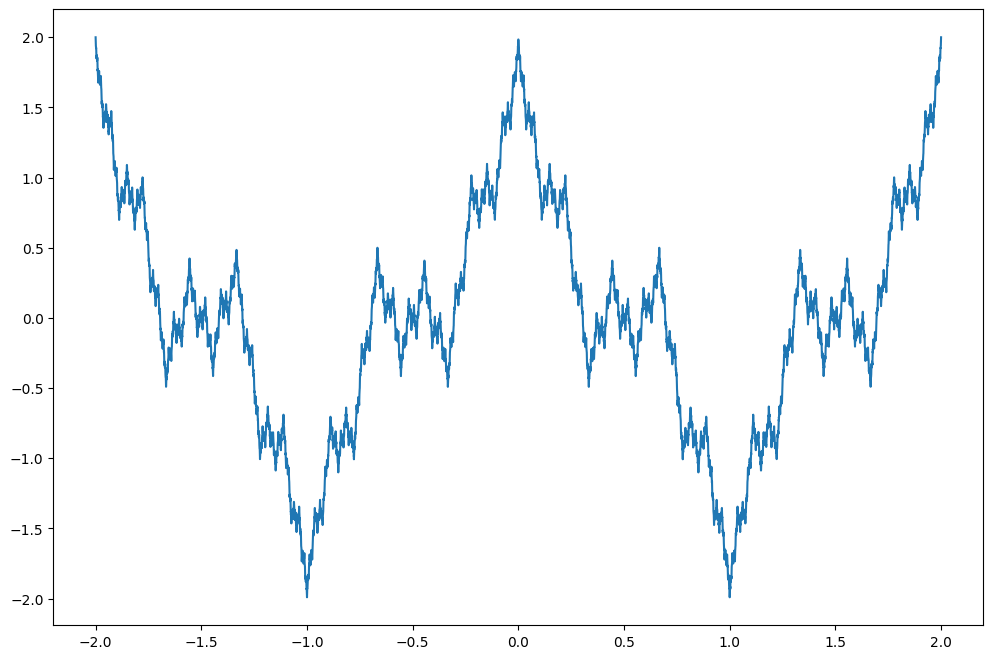

In [15]:
x = jnp.linspace(-2,2,10000)
plt.plot(x,[weierstrass(x_, n=100, a=1/2, b=3) for x_ in x]);

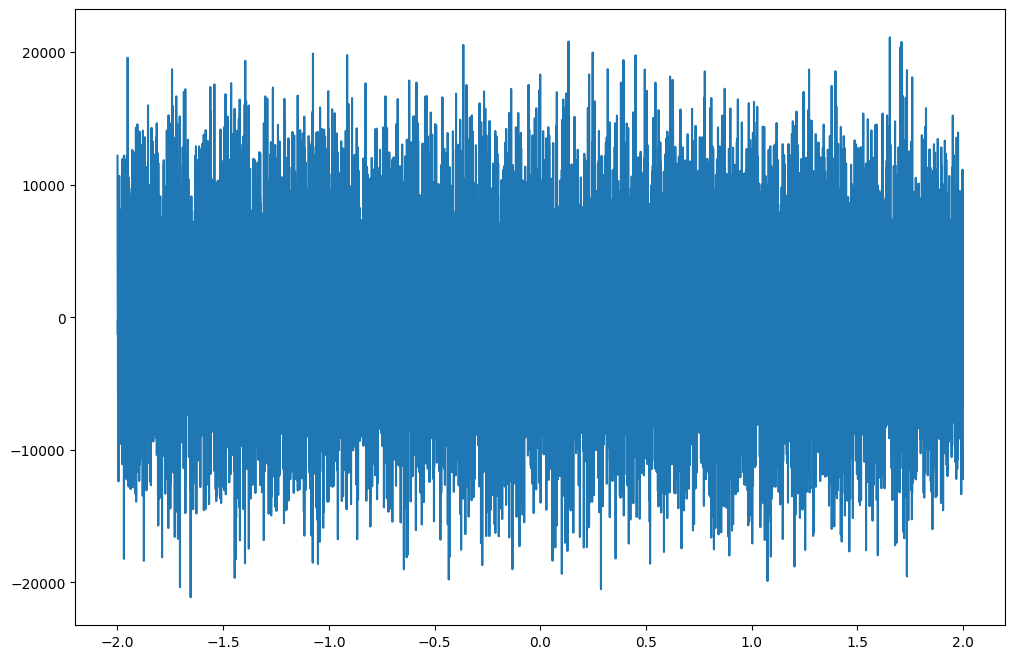

In [25]:
# derivative
w_n = partial(weierstrass, n=100)
plt.plot(x,jax.vmap(jax.grad(w_n))(x));

One thing to note here is `@jax.jit(static_argnames=['n', 'f'])`, this is needed since otherwise Jax would treat n, f as fixed variables when compiling. Another catch is that this program slows down considerably with larger n, unrolling python loops probably isn't very efficient. In production you should probably use `jax.lax.scan` instead.

We would expect the derivative to blow up for larger n, diverging in the limit. Let's check.

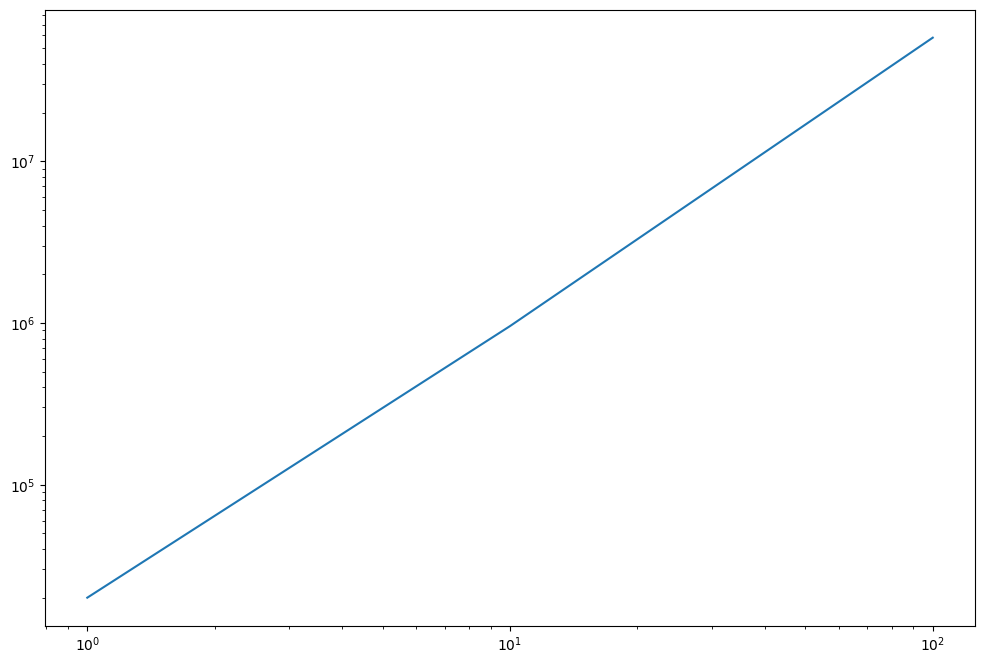

In [17]:
ns = 10**np.arange(3)
norms = []
for n in ns:
    w_n = partial(weierstrass, n=n)
    norms.append(jnp.linalg.norm(jax.vmap(jax.grad(w_n))(x),1))

plt.loglog(ns, norms)

We could also try to switch the orders of summation and differentiation.

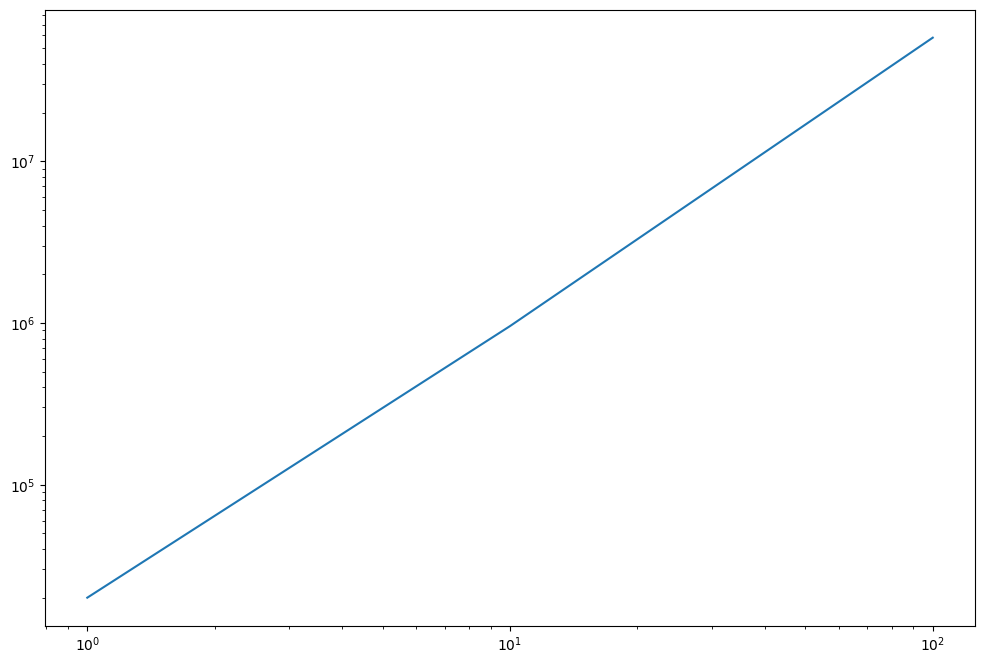

In [18]:
ns = 10**np.arange(3)
norms = []
for n in ns:
    wt_n = partial(w_term, n=n)
    w_n = partial(weierstrass, n=n, f=jax.grad(wt_n))
    norms.append(jnp.linalg.norm(jax.vmap(w_n)(x),1))

plt.loglog(ns, norms)

Not too surprisingly this looks exactly the same, we are dealing with finite sums after all.

### Portfolio Optimization

Assume we have two correlated financial assets and we want to find the optimal allocation that maximizes the Sharpe ratio $\frac{\mu}{\sigma}$.

In [19]:
np.random.seed(1)
mu = [.1, .09]
cov = np.random.rand(2,2)
cov = cov.T*cov
returns = np.random.multivariate_normal(mu, cov, size = 1000)

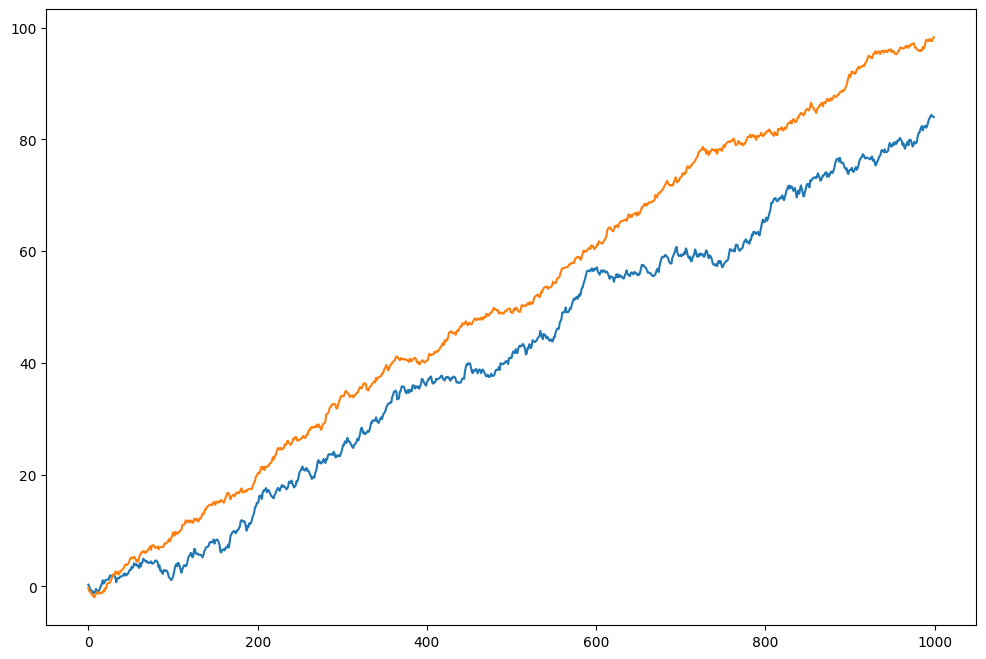

In [20]:
plt.plot(returns.cumsum(axis=0))

We want to find the optimal weights $w_i$ to allocate to asset 1 and 2 respectively. Let's parameterize as $w_1 = 1$, $w_2 = \theta$ and normalize the total portfolio in the end.

In [21]:
@jax.jit(static_argnames='returns')
def sharpe_ratio(theta, returns = returns):
    r = (returns[:,0] + returns[:,1]*theta)/(1+theta)

    return jnp.mean(r)/jnp.std(r)

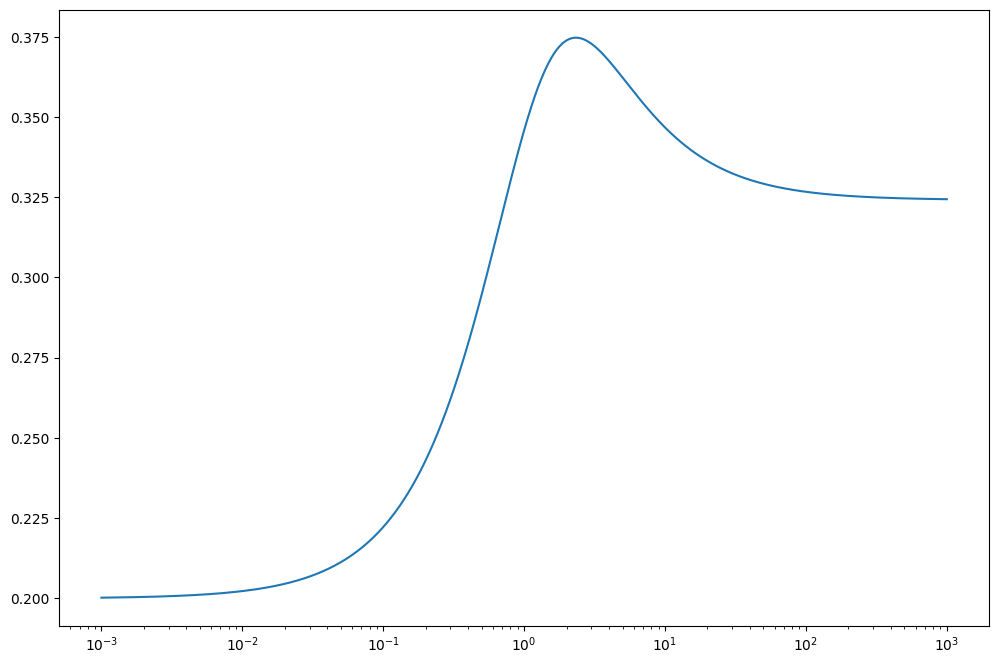

In [22]:
tt = np.logspace(-3,3, 1000)
plt.semilogx(tt,jax.vmap(sharpe_ratio)(tt))

Now that we know we can differentiate pretty much anything we could calculate $\frac{dS}{d\theta}$ and find the maximum using e.g. Euler's method. Here we just apply an out of the box method from optax.

In [23]:
import optax
from optax import adam

optimizer = adam(learning_rate = 1e-1)
theta = jnp.array([0.0])
opt_state = optimizer.init(theta)

for _ in range(1000):
  grads = jax.grad(lambda x : -sharpe_ratio(x))(theta)
  updates, opt_state = optimizer.update(grads, opt_state)
  theta = optax.apply_updates(theta, updates)

theta

Array([2.3339], dtype=float32)

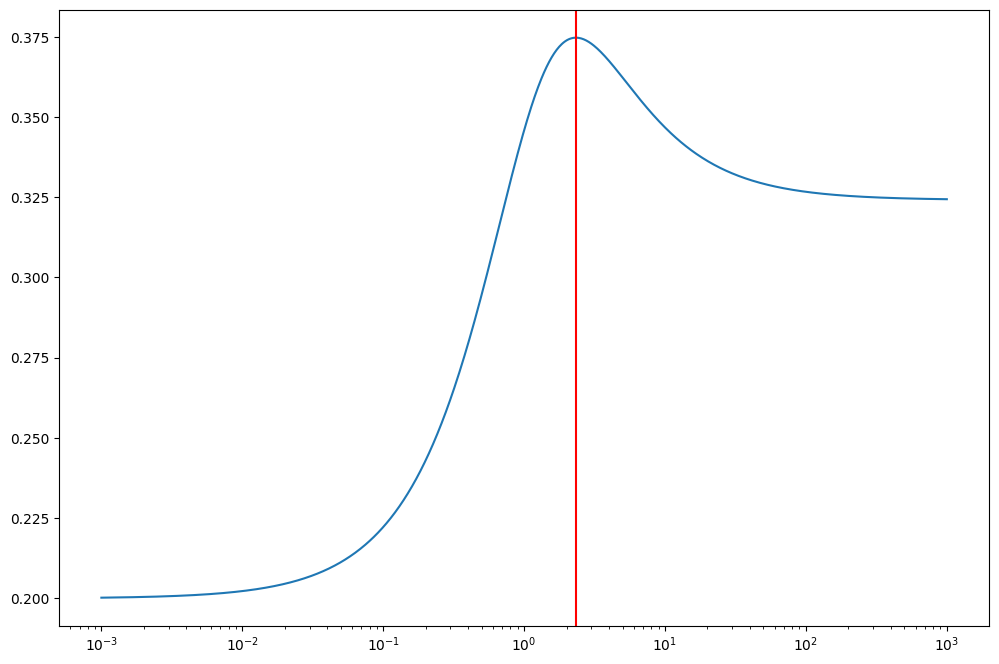

In [24]:
tt = np.logspace(-3,3, 1000)
plt.semilogx(tt,jax.vmap(sharpe_ratio)(tt))
plt.axvline(theta, c='red')

Convenient, in the olden days I might have used an optimization algorithm from e.g. scipy where I would either have to manually supply gradients or rely on black box optimization.

Autodiff opens up for a lot of interesting possibilities, for example differentiating through the solutions of ODEs, simulations, composing neural networks with arbitrary programs etc.

Here are some resources for digging deeper into autodiff.

[https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html)

[https://book.sciml.ai/notes/08-Forward-Mode_Automatic_Differentiation_(AD)_via_High_Dimensional_Algebras/](https://book.sciml.ai/notes/08-Forward-Mode_Automatic_Differentiation_(AD)_via_High_Dimensional_Algebras/)